In [9]:
!pip install -U transformers accelerate safetensors


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 97.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.2/507.2 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 98.7 MB/s eta 0:00:00
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.5.3
    Uninstalling safetensors-0.5.3:
      Successfully uninstalled safetensors-0.5.3
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.2
    Uninstalling tokenizers-0.21.2:
      Successfully uninstalled tokenizers-0.21.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.53.3
    Uninstalling transformers-4.53.3:
      Successfully uninstalled transformers-4.53.3
  Attempting uninstall: accelerate
    Found existing installation: ac

In [29]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from glob import glob
from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects
import seaborn as sns
import pandas as pd
import random
from skimage import exposure
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from sklearn.model_selection import StratifiedKFold
import pandas as pd
from tqdm import tqdm
import gc
import warnings
import random
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

from sklearn.metrics import f1_score
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.cuda.amp import GradScaler, autocast
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set(style='whitegrid')

In [13]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [14]:
BASE_DIR = "/kaggle/input/recodai-luc-scientific-image-forgery-detection"
train_image_paths = sorted(glob(os.path.join(BASE_DIR, "train_images", "*", "*.png")))
train_mask_paths = sorted(glob(os.path.join(BASE_DIR, "train_masks", "*.npy")))
test_image_paths = sorted(glob(os.path.join(BASE_DIR, "test_images", "*", "*.png")))
IMG_SIZE = 512
BATCH_SIZE = 8  # Reduced for stability on GPU
EPOCHS = 50
LR = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_FOLDS = 5
PATIENCE = 5
MIN_AREA = 100  # For post-processing small objects removal

print(f"Train images: {len(train_image_paths)}, Train masks: {len(train_mask_paths)}")
print(f"Test images: {len(test_image_paths)}")

Train images: 5128, Train masks: 2751
Test images: 0


In [15]:
def get_id(path):
    return os.path.splitext(os.path.basename(path))[0]

mask_map = {get_id(p): p for p in train_mask_paths}
pairs = []
for img_path in train_image_paths:
    cid = get_id(img_path)
    if cid in mask_map:
        mask_path = mask_map[cid]
        has_forgery = True
    else:
        mask_path = None
        has_forgery = False
    pairs.append({"img_path": img_path, "mask_path": mask_path, "has_forgery": has_forgery})

In [16]:
total_train = len(pairs)
forged_count = sum(p['has_forgery'] for p in pairs)
authentic_count = total_train - forged_count
auth_ratio = authentic_count / total_train if total_train > 0 else 0
print(f"Total train images: {total_train}")
print(f"Forged images: {forged_count} ({forged_count / total_train:.2%})")
print(f"Authentic images: {authentic_count} ({auth_ratio:.2%})")

Total train images: 5128
Forged images: 5128 (100.00%)
Authentic images: 0 (0.00%)


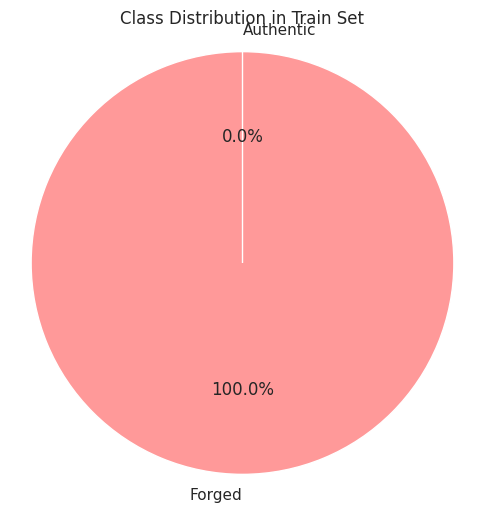

In [17]:
labels = ['Forged', 'Authentic']
sizes = [forged_count, authentic_count]
colors = ['#ff9999', '#66b3ff']
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution in Train Set')
plt.axis('equal')
plt.show()

In [18]:
def load_mask(mask_path, img_shape):
    H, W = img_shape[:2]
    if H == 0 or W == 0:
        return np.zeros((0, 0), dtype=np.uint8)
    if mask_path is None:
        return np.zeros((H, W), dtype=np.uint8)
    try:
        mask = np.load(mask_path)
    except Exception as e:
        print(f"Error loading mask {mask_path}: {e}")
        return np.zeros((H, W), dtype=np.uint8)
    if mask.size == 0:
        return np.zeros((H, W), dtype=np.uint8)
    if mask.ndim == 1 or mask.size != H * W:
        return np.zeros((H, W), dtype=np.uint8)
    else:
        try:
            mask = mask.reshape((H, W))
        except:
            return np.zeros((H, W), dtype=np.uint8)
    mask = (mask > 0).astype(np.uint8)
    return mask

In [19]:
fg_ratios = []
n_components = []
image_shapes = []  # (H, W, C)
is_grayscale = []
mean_intensity = []
for p in pairs:
    img = cv2.imread(p["img_path"])
    if img is None or img.shape[0] == 0 or img.shape[1] == 0:
        continue
    image_shapes.append(img.shape)
    
    if len(img.shape) == 2 or np.all(img[:,:,0] == img[:,:,1]) and np.all(img[:,:,1] == img[:,:,2]):
        is_grayscale.append(True)
        gray = img if len(img.shape) == 2 else cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        is_grayscale.append(False)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    mean_intensity.append(np.mean(gray))
    
    if p["has_forgery"]:
        mask = load_mask(p["mask_path"], img.shape)
        fg_ratios.append(mask.mean())
        labeled = label(mask)
        props = regionprops(labeled)
        n_components.append(len(props))

df_stats = pd.DataFrame({
    'Foreground Ratio': fg_ratios,
    'Num Components': n_components
})
print("\nSummary Stats for Forged Images:")
print(df_stats.describe())


Summary Stats for Forged Images:
       Foreground Ratio  Num Components
count       5128.000000     5128.000000
mean           0.043223        1.493955
std            0.067422        1.093789
min            0.000000        0.000000
25%            0.000000        0.000000
50%            0.009650        2.000000
75%            0.066881        2.000000
max            0.522728        5.000000


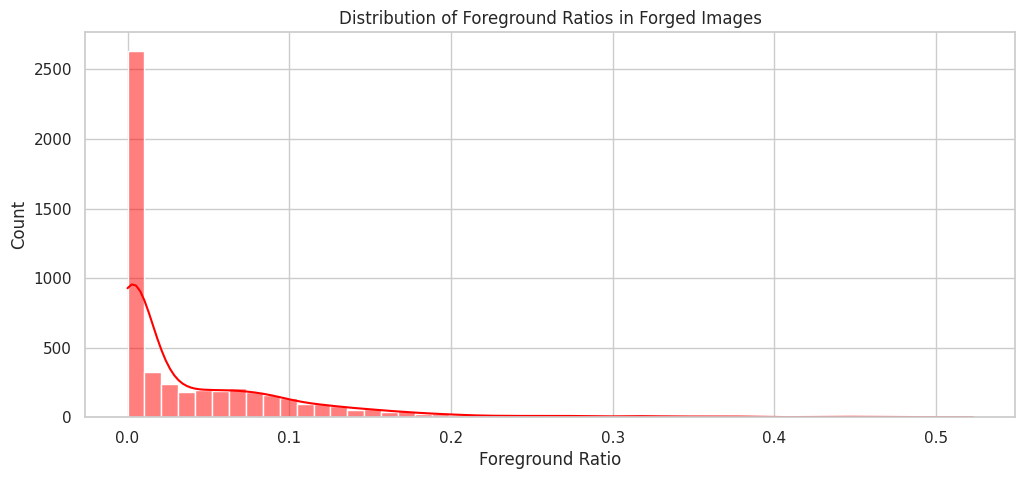

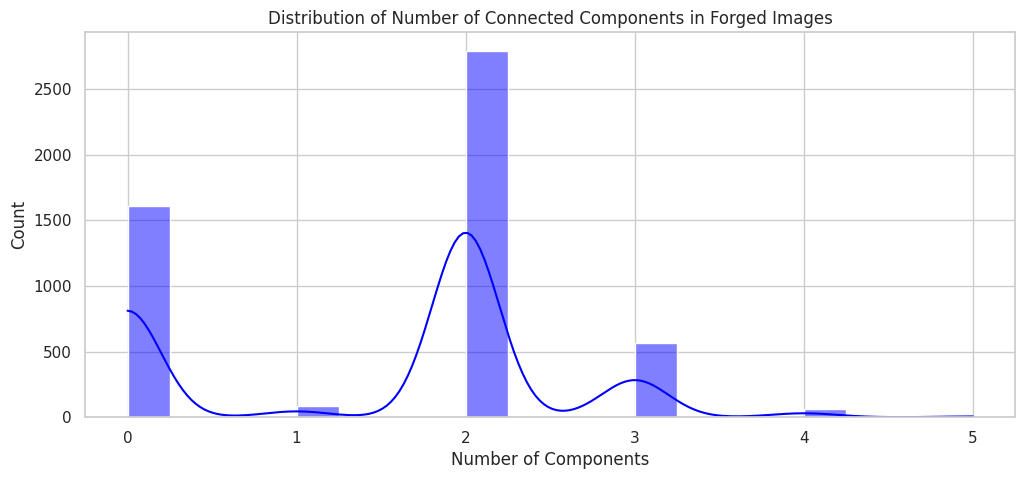

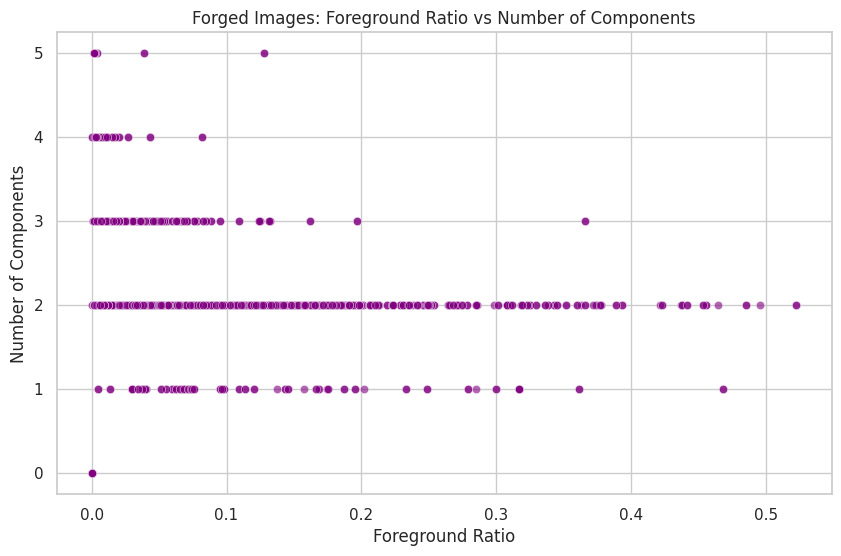

In [20]:
plt.figure(figsize=(12, 5))
sns.histplot(fg_ratios, bins=50, kde=True, color='red')
plt.title("Distribution of Foreground Ratios in Forged Images")
plt.xlabel("Foreground Ratio")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(12, 5))
sns.histplot(n_components, bins=20, kde=True, color='blue')
plt.title("Distribution of Number of Connected Components in Forged Images")
plt.xlabel("Number of Components")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fg_ratios, y=n_components, alpha=0.6, color='purple')
plt.xlabel("Foreground Ratio")
plt.ylabel("Number of Components")
plt.title("Forged Images: Foreground Ratio vs Number of Components")
plt.show()

In [21]:
def get_shapes(paths):
    shapes = []
    for path in paths:
        img = cv2.imread(path)
        if img is not None:
            shapes.append(img.shape[:2])  # (H, W)
    return shapes


Train Image Shapes Summary:
            Height        Width
count  5128.000000  5128.000000
mean    692.641576   930.980109
std     678.917187   729.418964
min      64.000000    74.000000
25%     256.000000   400.500000
50%     512.000000   696.000000
75%     706.000000  1024.000000
max    3888.000000  3888.000000

Test Image Shapes Summary:
       Height Width
count       0     0
unique      0     0
top       NaN   NaN
freq      NaN   NaN


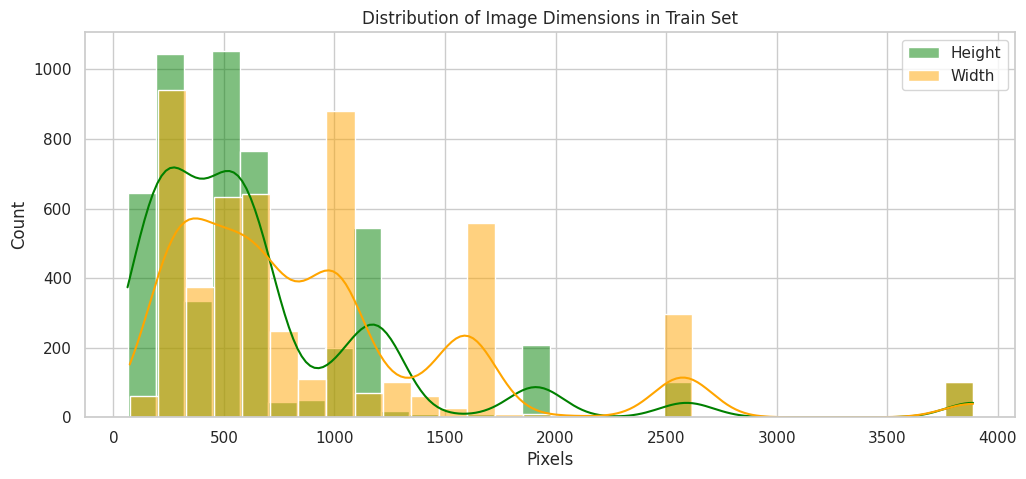

Grayscale images ratio: 46.61%


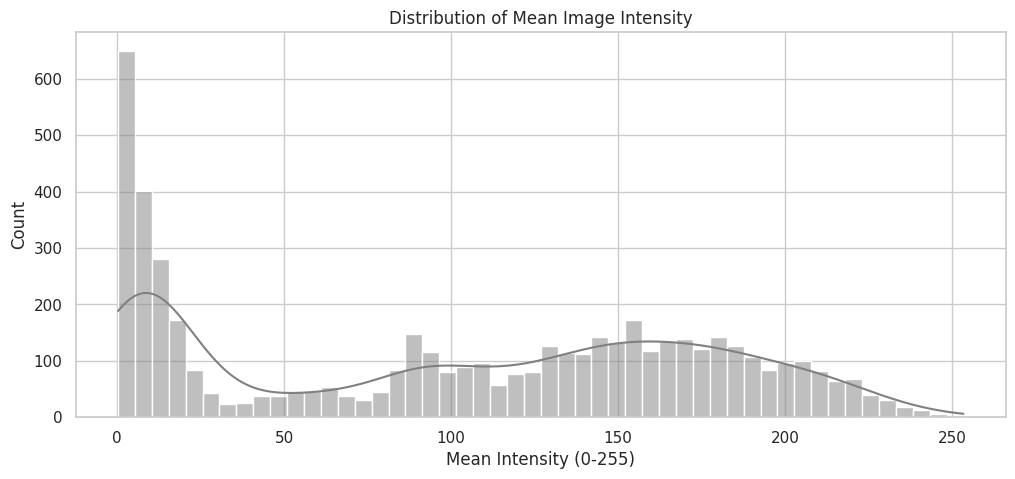

In [22]:
train_shapes = get_shapes(train_image_paths)
test_shapes = get_shapes(test_image_paths)
df_train_shapes = pd.DataFrame(train_shapes, columns=['Height', 'Width'])
df_test_shapes = pd.DataFrame(test_shapes, columns=['Height', 'Width'])
print("\nTrain Image Shapes Summary:")
print(df_train_shapes.describe())
print("\nTest Image Shapes Summary:")
print(df_test_shapes.describe())

plt.figure(figsize=(12, 5))
sns.histplot(df_train_shapes['Height'], bins=30, kde=True, color='green', label='Height')
sns.histplot(df_train_shapes['Width'], bins=30, kde=True, color='orange', label='Width')
plt.title("Distribution of Image Dimensions in Train Set")
plt.xlabel("Pixels")
plt.ylabel("Count")
plt.legend()
plt.show()

grayscale_ratio = sum(is_grayscale) / len(is_grayscale) if len(is_grayscale) > 0 else 0
print(f"Grayscale images ratio: {grayscale_ratio:.2%}")

plt.figure(figsize=(12, 5))
sns.histplot(mean_intensity, bins=50, kde=True, color='gray')
plt.title("Distribution of Mean Image Intensity")
plt.xlabel("Mean Intensity (0-255)")
plt.ylabel("Count")
plt.show()

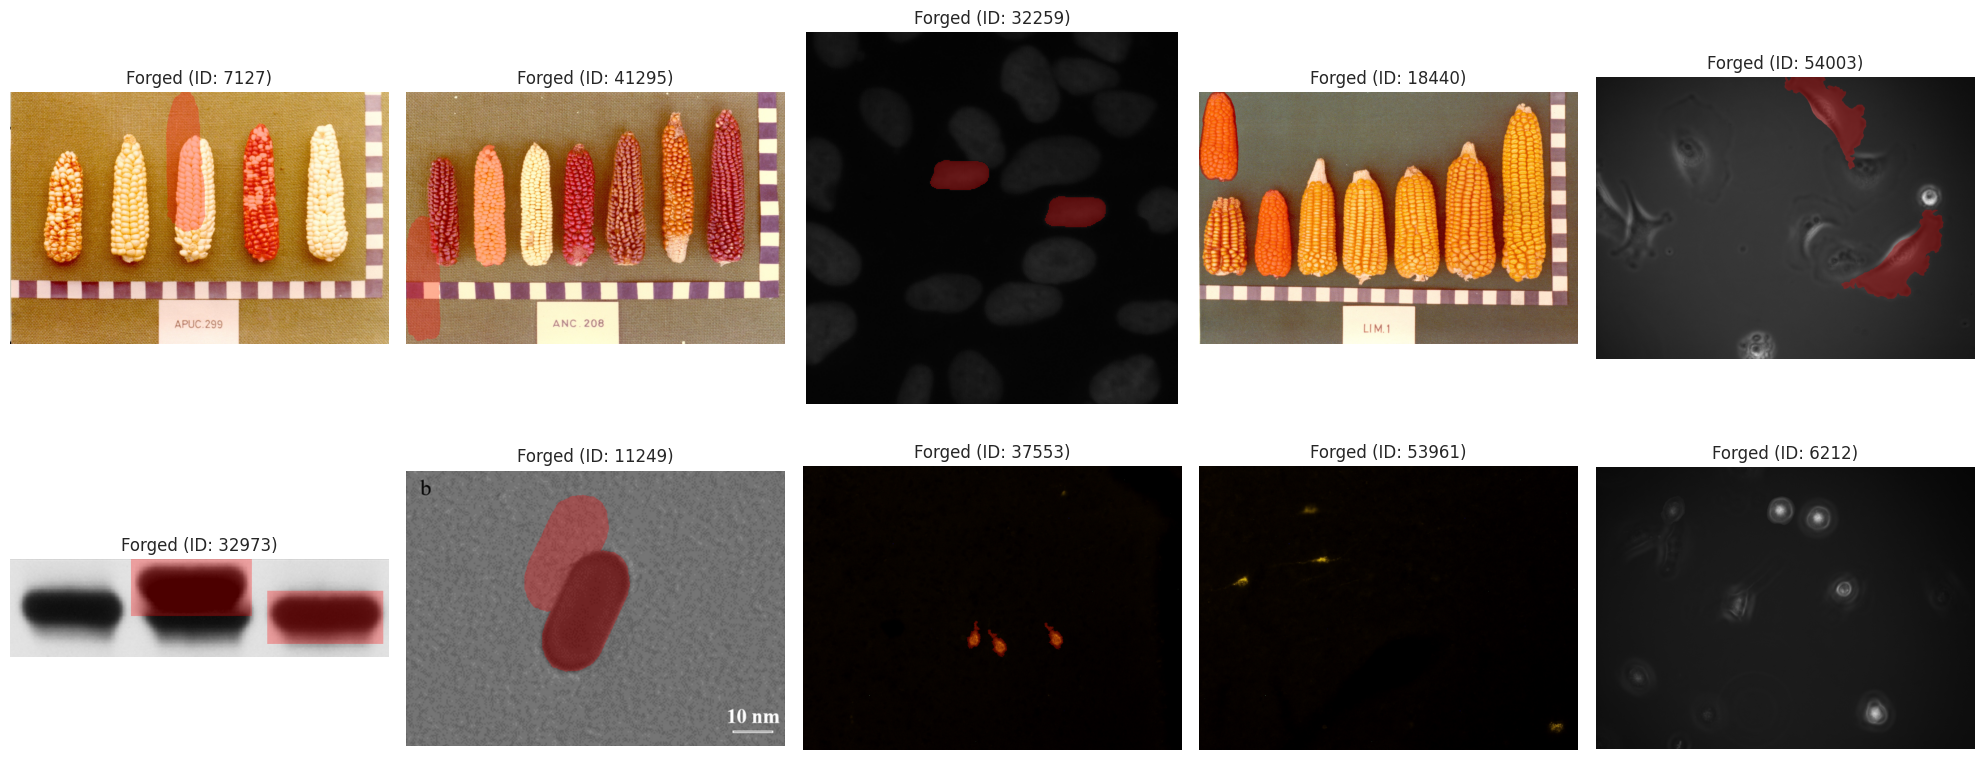

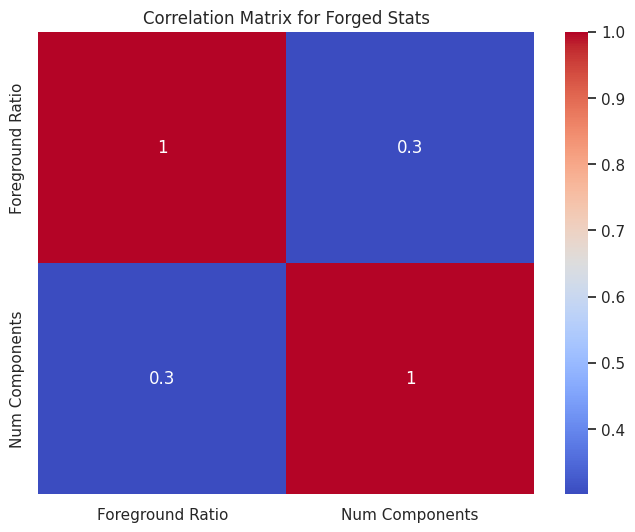

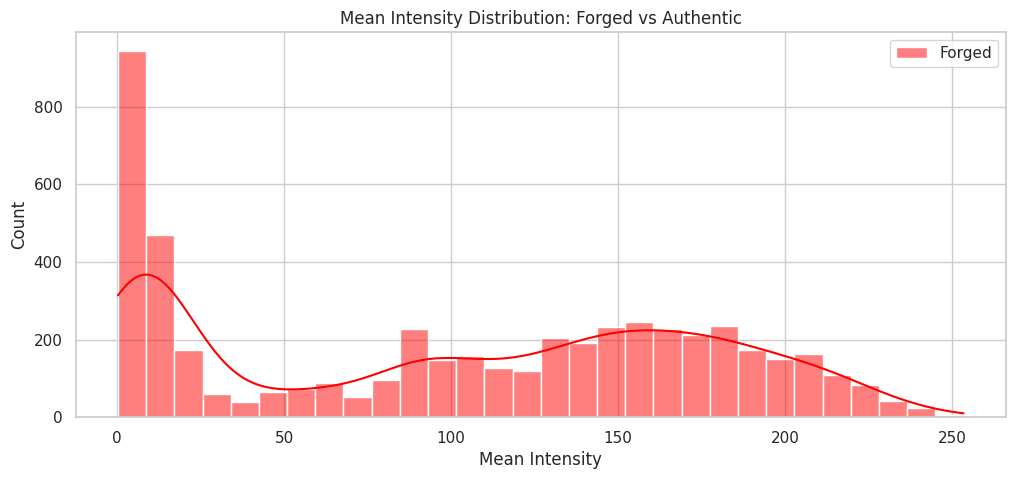

EDA Complete! This provides a strong foundation for model development.


In [24]:
def show_samples(pairs, n=20):
    forged_samples = [p for p in pairs if p["has_forgery"]]
    authentic_samples = [p for p in pairs if not p["has_forgery"]]
    
    forged_selected = random.sample(forged_samples, min(n//2, len(forged_samples)))
    authentic_selected = random.sample(authentic_samples, min(n//2, len(authentic_samples)))
    
    samples = forged_selected + authentic_selected
    random.shuffle(samples)
    
    rows = (n + 4) // 5
    plt.figure(figsize=(20, 4 * rows))
    for i, p in enumerate(samples):
        img = cv2.imread(p["img_path"])
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = load_mask(p["mask_path"], img.shape)
        img_to_show = img.copy()
        if p["has_forgery"]:
            overlay = img.copy()
            overlay[mask == 1] = [255, 0, 0]  # red overlay
            img_to_show = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)
        plt.subplot(rows, 5, i + 1)
        plt.imshow(img_to_show)
        plt.axis("off")
        plt.title(f"{'Forged' if p['has_forgery'] else 'Authentic'} (ID: {get_id(p['img_path'])})")
    plt.tight_layout()
    plt.show()

show_samples(pairs, n=20)

corr_matrix = df_stats.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix for Forged Stats")
plt.show()
forged_intensity = [mean_intensity[i] for i, p in enumerate(pairs) if p["has_forgery"]]
authentic_intensity = [mean_intensity[i] for i, p in enumerate(pairs) if not p["has_forgery"]]
plt.figure(figsize=(12, 5))
sns.histplot(forged_intensity, bins=30, kde=True, color='red', label='Forged')
sns.histplot(authentic_intensity, bins=30, kde=True, color='blue', label='Authentic')
plt.title("Mean Intensity Distribution: Forged vs Authentic")
plt.xlabel("Mean Intensity")
plt.ylabel("Count")
plt.legend()
plt.show()

print("EDA Complete! This provides a strong foundation for model development.")

In [25]:
train_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussNoise(p=0.3),
    A.CLAHE(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

tta_augs = [
    A.Compose([A.HorizontalFlip(p=1.0), A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), ToTensorV2()]),
    A.Compose([A.VerticalFlip(p=1.0), A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), ToTensorV2()]),
    A.Compose([A.RandomRotate90(p=1.0), A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), ToTensorV2()])
]

In [26]:
class ForgeryDataset(Dataset):
    def __init__(self, img_paths, mask_paths=None, aug=None):
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.aug = aug

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = cv2.imread(img_path)
        if img is None:
            raise ValueError(f"Image not found: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]
        mask = np.zeros((H, W), dtype=np.uint8)
        if self.mask_paths is not None and self.mask_paths[idx] is not None:
            mask = load_mask(self.mask_paths[idx], img.shape)
        if self.aug:
            augmented = self.aug(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask'].unsqueeze(0).float() if 'mask' in augmented else torch.zeros((1, IMG_SIZE, IMG_SIZE), dtype=torch.float)
        else:
            img = val_aug(image=img)['image']
            mask = torch.from_numpy(mask).unsqueeze(0).float()
        return img, mask

In [27]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = smp.encoders.get_encoder('efficientnet-b4', pretrained='imagenet')
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(self.model.out_channels[-1], 1)

    def forward(self, x):
        features = self.model(x)[-1]
        pooled = self.pool(features).squeeze(-1).squeeze(-1)
        return torch.sigmoid(self.fc(pooled))

In [31]:
def get_unet_model():
    return smp.Unet(
        encoder_name="efficientnet-b4",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
        activation=None
    ).to(DEVICE)

def get_segformer_model():
    id2label = {0: "background", 1: "forgery"}
    label2id = {v: k for k, v in id2label.items()}
    model = SegformerForSemanticSegmentation.from_pretrained(
        "nvidia/mit-b3", 
        num_labels=2, 
        id2label=id2label, 
        label2id=label2id, 
        ignore_mismatched_sizes=True
    )
    return model.to(DEVICE)

processor = SegformerImageProcessor.from_pretrained("nvidia/mit-b3")

preprocessor_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

In [32]:
dice_loss = smp.losses.DiceLoss(mode='binary', from_logits=True)
bce_loss = nn.BCEWithLogitsLoss()
def criterion(pred, target):
    return dice_loss(pred, target) + bce_loss(pred, target)

def classifier_criterion(pred, target):
    return nn.BCELoss()(pred, target)

# F1 Score
def compute_f1(gt, pred):
    gt = gt.flatten()
    pred = pred.flatten()
    return f1_score(gt, pred, average='binary', zero_division=0)

# Post-processing
def post_process_mask(mask):
    mask = remove_small_objects(mask > 0, min_size=MIN_AREA, connectivity=1)
    return mask.astype(np.uint8)

# Multi-scale Inference
scales = [0.75, 1.0, 1.25]

def multi_scale_predict(model, img, model_type='unet'):
    preds = []
    original_size = img.shape[1:]  # (H, W)
    for scale in scales:
        resized_img = F.interpolate(img, size=(int(original_size[0]*scale), int(original_size[1]*scale)), mode='bilinear')
        if model_type == 'segformer':
            inputs = processor(resized_img.cpu().numpy().transpose(0,2,3,1), return_tensors="pt").to(DEVICE)
            with torch.no_grad():
                outputs = model(**inputs)
            pred = outputs.logits
            pred = F.interpolate(pred, size=original_size, mode='bilinear')
        else:
            with torch.no_grad():
                pred = model(resized_img)
            pred = F.interpolate(pred, size=original_size, mode='bilinear')
        preds.append(torch.sigmoid(pred))
    return torch.mean(torch.stack(preds), dim=0)

# TTA Inference
def tta_predict(model, img, model_type='unet'):
    preds = []
    for aug in [val_aug] + tta_augs:
        augmented = aug(image=img.cpu().numpy().transpose(0,2,3,1)[0])['image'].unsqueeze(0).to(DEVICE)
        if model_type == 'segformer':
            inputs = processor(augmented.cpu().numpy().transpose(0,2,3,1), return_tensors="pt").to(DEVICE)
            with torch.no_grad():
                outputs = model(**inputs)
            pred = outputs.logits
            pred = F.interpolate(pred, size=img.shape[2:], mode='bilinear')  # Adjust for SegFormer output
            pred = pred[:,1:2,:,:]  # Select forgery channel
        else:
            with torch.no_grad():
                pred = model(augmented)
        # Reverse aug if needed (for flips, etc.)
        if 'HorizontalFlip' in str(aug):
            pred = pred.flip(3)
        elif 'VerticalFlip' in str(aug):
            pred = pred.flip(2)
        elif 'RandomRotate90' in str(aug):
            pred = pred.rot90(-1, [2,3])  # Approximate reverse
        preds.append(torch.sigmoid(pred))
    return torch.mean(torch.stack(preds), dim=0)

# Ensemble Predict
def ensemble_predict(models, img):
    preds = []
    for model, m_type in models:
        pred = tta_predict(model, multi_scale_predict(model, img, m_type), m_type)
        preds.append(pred)
    return torch.mean(torch.stack(preds), dim=0)

In [ ]:
def train_fold(fold, models_info):
    img_paths, mask_paths, labels, _ = get_data()
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    for i, (train_idx, val_idx) in enumerate(skf.split(img_paths, labels)):
        if i != fold:
            continue
        train_ds = ForgeryDataset([img_paths[j] for j in train_idx], [mask_paths[j] for j in train_idx], train_aug)
        val_ds = ForgeryDataset([img_paths[j] for j in val_idx], [mask_paths[j] for j in val_idx], val_aug)
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
        
        # Models
        models = []
        optimizers = []
        schedulers = []
        classifiers = []
        class_optims = []
        for m_type in models_info:
            if m_type == 'unet':
                seg_model = get_unet_model()
            elif m_type == 'segformer':
                seg_model = get_segformer_model()
            models.append((seg_model, m_type))
            optimizer = torch.optim.AdamW(seg_model.parameters(), lr=LR)
            scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)
            optimizers.append(optimizer)
            schedulers.append(scheduler)
            
            # Classifier
            clf = Classifier().to(DEVICE)
            class_opt = torch.optim.AdamW(clf.parameters(), lr=LR)
            classifiers.append(clf)
            class_optims.append(class_opt)
        
        best_score = 0
        patience_cnt = 0
        scaler = GradScaler()
        
        for epoch in range(EPOCHS):
            for seg_model, _ in models:
                seg_model.train()
            for clf in classifiers:
                clf.train()
            
            train_loss = 0
            train_clf_loss = 0
            for img, mask in tqdm(train_loader, desc=f"Fold {fold} Epoch {epoch+1} Train"):
                img, mask = img.to(DEVICE), mask.to(DEVICE)
                labels = (mask.sum(dim=(1,2,3)) > 0).float().unsqueeze(1)
                
                with autocast():
                    # Classifier
                    for clf, class_opt in zip(classifiers, class_optims):
                        clf_pred = clf(img)
                        clf_loss = classifier_criterion(clf_pred, labels)
                        scaler.scale(clf_loss).backward()
                        scaler.step(class_opt)
                        scaler.update()
                        class_opt.zero_grad()
                        train_clf_loss += clf_loss.item()
                    
                    # Segmentation if gated
                    gate = all(clf(img) > 0.5 for clf in classifiers)
                    if gate.any():
                        gated_img = img[gate]
                        gated_mask = mask[gate]
                        for (seg_model, m_type), opt in zip(models, optimizers):
                            if m_type == 'segformer':
                                inputs = processor(gated_img.cpu().numpy().transpose(0,2,3,1), return_tensors="pt").to(DEVICE)
                                pred = seg_model(**inputs).logits
                                pred = F.interpolate(pred, size=(IMG_SIZE, IMG_SIZE), mode='bilinear')
                                pred = pred[:,1:2,:,:]  # Forgery channel
                            else:
                                pred = seg_model(gated_img)
                            loss = criterion(pred, gated_mask)
                            scaler.scale(loss).backward()
                            scaler.step(opt)
                            scaler.update()
                            opt.zero_grad()
                            train_loss += loss.item()
            
            # Validation
            for seg_model, _ in models:
                seg_model.eval()
            for clf in classifiers:
                clf.eval()
            
            val_scores = []
            with torch.no_grad():
                for img, mask in tqdm(val_loader, desc=f"Fold {fold} Epoch {epoch+1} Val"):
                    img = img.to(DEVICE)
                    gt = mask.cpu().numpy().squeeze(1)
                    # Classifier gate
                    gate_probs = torch.mean(torch.stack([clf(img) for clf in classifiers]), dim=0)
                    pred = torch.zeros_like(mask).to(DEVICE)
                    gated_idx = gate_probs > 0.5
                    if gated_idx.any():
                        gated_img = img[gated_idx.squeeze()]
                        ens_pred = ensemble_predict(models, gated_img)
                        pred[gated_idx] = ens_pred
                    pred_prob = torch.sigmoid(pred).cpu().numpy().squeeze(1)
                    pred_bin = (pred_prob > 0.5).astype(np.uint8)
                    for i in range(len(pred_bin)):
                        pred_bin[i] = post_process_mask(pred_bin[i])
                        val_scores.append(compute_f1(gt[i], pred_bin[i]))
            
            score = np.mean(val_scores)
            print(f"Fold {fold} Epoch {epoch+1} - Val F1: {score:.4f}")
            
            for sch in schedulers:
                sch.step(score)
            
            if score > best_score:
                best_score = score
                for idx, (model, m_type) in enumerate(models):
                    torch.save(model.state_dict(), f"best_{m_type}_fold{fold}.pth")
                for idx, clf in enumerate(classifiers):
                    torch.save(clf.state_dict(), f"best_clf_{idx}_fold{fold}.pth")
                patience_cnt = 0
            else:
                patience_cnt += 1
                if patience_cnt > PATIENCE:
                    break